## Step 1: Load Dataset

In [2]:
import pandas as pd

# Load dataset (after downloading from Kaggle)
df = pd.read_csv("data.csv")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Step 2: Preprocessing

In [5]:
from sklearn.model_selection import train_test_split

# Drop empty column and ID
df = df.drop(columns=["Unnamed: 32", "id"])
df = df.dropna()

# Features and target
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"].map({"M":1, "B":0})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (455, 30)
Test set size: (114, 30)


## Step 3: Train Models

SVM with different kernels

In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

kernels = ["linear", "rbf", "sigmoid", "poly"]

print("=== Support Vector Machine Results ===")
for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"SVM Kernel={k} Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("-"*40)


=== Support Vector Machine Results ===
SVM Kernel=linear Accuracy: 0.956140350877193
Confusion Matrix:
 [[70  1]
 [ 4 39]]
----------------------------------------
SVM Kernel=rbf Accuracy: 0.9473684210526315
Confusion Matrix:
 [[71  0]
 [ 6 37]]
----------------------------------------
SVM Kernel=sigmoid Accuracy: 0.4649122807017544
Confusion Matrix:
 [[47 24]
 [37  6]]
----------------------------------------
SVM Kernel=poly Accuracy: 0.9473684210526315
Confusion Matrix:
 [[71  0]
 [ 6 37]]
----------------------------------------


KNN with Elbow Method

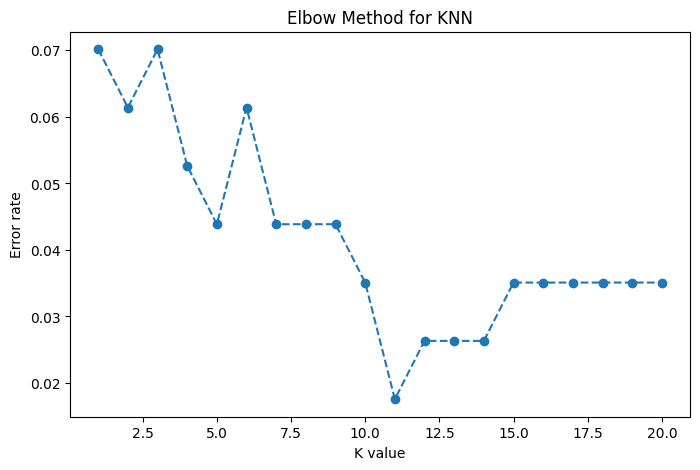

=== K-Nearest Neighbors Results ===
KNN (k=5) Accuracy: 0.956140350877193
Confusion Matrix:
 [[71  0]
 [ 5 38]]


In [7]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

error_rates = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, y_pred))

plt.figure(figsize=(8,5))
plt.plot(range(1,21), error_rates, marker='o', linestyle='--')
plt.xlabel("K value")
plt.ylabel("Error rate")
plt.title("Elbow Method for KNN")
plt.show()

# Train with optimal K (example: 5)
optimal_k = 5
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("=== K-Nearest Neighbors Results ===")
print(f"KNN (k={optimal_k}) Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
